# Experimental Comparison of Local Search Algorithms on 8-Puzzle and 8-Queens

**Student:** Francisco Pico, Christian Ballester  
**Course:** Artificial Intelligence  
**Assignment:** 
Programming assignment Chapter 4


## Abstract

This report compares local search algorithms on randomly generated 8-puzzle and 8-queens instances. The algorithms tested are steepest-ascent hill climbing, first-choice hill climbing, random-restart hill climbing, and simulated annealing. The main measurements are solved percentage, search cost, and runtime. Results are grouped by optimal solution cost and visualized using tables and figures.

## I. Introduction

Exercise 4.4 asks for a comparison of local search algorithms on 8-puzzle and 8-queens instances. The experiment requires generating many instances, solving them where possible, measuring search cost and solved percentage, graphing those measurements against optimal solution cost, and commenting on the results.

Local search methods are useful because they often use less memory than full tree-search methods. However, they can become stuck in local maxima, plateaus, or ridges. This experiment studies those tradeoffs using two classic AI problems.

## II. Background

### A. Steepest-Ascent Hill Climbing

Steepest-ascent hill climbing checks the neighbors of the current state and moves to the neighbor with the best value. It stops when no neighbor improves the current value.

### B. First-Choice Hill Climbing

First-choice hill climbing checks neighbors in random order and moves to the first one that improves the current state. This can reduce the number of evaluated neighbors, but it may not choose the best available move.

### C. Random-Restart Hill Climbing

Random-restart hill climbing repeats hill climbing from multiple starting states. This increases the probability of finding a solution, but it also increases total search cost.

### D. Simulated Annealing

Simulated annealing sometimes accepts worse moves early in the search. This can help escape local optima. As the temperature decreases, the algorithm becomes more greedy.

## III. Experimental Methodology

The main search algorithms come from the UC Berkeley/AIMA Python repository. This notebook adds problem classes and measurement code so that the algorithms can be compared.

**Table I. Problem formulations used in the experiment.**

| Problem | State Representation | Goal Test | Value Function |
|---|---|---|---|
| 8-puzzle | Tuple of nine numbers; `0` is the blank | State equals goal board | Negative Manhattan distance |
| 8-queens | Tuple of eight row positions, one per column | Zero attacking queen pairs | `28 - attacking_pairs` |

Table I summarizes the state representation, goal test, and value function for each problem.

**Table II. Algorithms compared in the experiment.**

| Algorithm | Main Idea | Expected Strength | Expected Weakness |
|---|---|---|---|
| Steepest-ascent hill climbing | Select best neighbor | Low cost | Can stop at local optimum |
| First-choice hill climbing | Select first improving neighbor | Fewer evaluations | May miss better moves |
| Random-restart hill climbing | Repeat hill climbing attempts | Higher solved percentage | Higher cost |
| Simulated annealing | Sometimes accepts worse moves | Can escape local optima | Sensitive to schedule |

Table II lists the algorithms compared in this experiment.

## IV. Setup and AIMA Repository Check

Run this cell first. It checks that required Python packages are available, clones the AIMA repository if needed, adds it to the Python path, and verifies that the AIMA search functions can be imported.

If this cell fails, the rest of the notebook will not run.

In [62]:
import sys
import subprocess
from pathlib import Path

def run_command(command):
    print("Running:", " ".join(command))
    result = subprocess.run(command, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(
            "Command failed: " + " ".join(command) +
            "\nIf this happened during git clone, make sure Git and internet access are available."
        )

# Install common notebook dependencies if they are missing.
for package in ["numpy", "pandas", "matplotlib"]:
    try:
        __import__(package)
    except ImportError:
        run_command([sys.executable, "-m", "pip", "install", package])

AIMA_DIR = Path("aima-python")

if not (AIMA_DIR / "search.py").exists():
    print("AIMA repository not found. Cloning it now...")
    run_command(["git", "clone", "--depth", "1", "https://github.com/aimacode/aima-python.git"])
else:
    print("AIMA repository already found.")

sys.path.insert(0, str(AIMA_DIR.resolve()))

try:
    from search import Problem, Node, astar_search, hill_climbing, simulated_annealing, exp_schedule
    print("AIMA search functions imported successfully.")
except Exception as error:
    print("The AIMA repository was found, but importing search.py failed.")
    print("Error:", repr(error))
    print("\nTry running this in a terminal:")
    print("pip install numpy scipy networkx sortedcontainers ipythonblocks")
    raise

AIMA repository already found.
AIMA search functions imported successfully.


## V. General Imports and Constants

In [63]:
import random
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

GOAL_8PUZZLE = (1, 2, 3, 4, 5, 6, 7, 8, 0)
N_QUEENS = 8
MAX_QUEEN_PAIRS = N_QUEENS * (N_QUEENS - 1) // 2

print("General imports completed.")

General imports completed.


## VI. Problem Definitions and Measurement Utilities

The following classes define the two problems using the AIMA `Problem` interface. The algorithms themselves are imported from the AIMA repository.

In [64]:
class InstrumentedProblem(Problem):
    def __init__(self, initial, goal=None):
        super().__init__(initial, goal)
        self.value_calls = 0
        self.action_calls = 0
        self.result_calls = 0

    @property
    def search_cost(self):
        return self.value_calls


def manhattan_8puzzle(state, goal=GOAL_8PUZZLE):
    total = 0
    for tile in range(1, 9):
        i = state.index(tile)
        j = goal.index(tile)
        row_i, col_i = divmod(i, 3)
        row_j, col_j = divmod(j, 3)
        total += abs(row_i - row_j) + abs(col_i - col_j)
    return total


class EightPuzzleLocalSearch(InstrumentedProblem):
    def __init__(self, initial, goal=GOAL_8PUZZLE):
        super().__init__(tuple(initial), tuple(goal))

    def find_blank_square(self, state):
        return state.index(0)

    def actions(self, state):
        self.action_calls += 1
        possible_actions = ["UP", "DOWN", "LEFT", "RIGHT"]
        blank = self.find_blank_square(state)

        if blank % 3 == 0:
            possible_actions.remove("LEFT")
        if blank < 3:
            possible_actions.remove("UP")
        if blank % 3 == 2:
            possible_actions.remove("RIGHT")
        if blank > 5:
            possible_actions.remove("DOWN")

        return possible_actions

    def result(self, state, action):
        self.result_calls += 1
        blank = self.find_blank_square(state)
        new_state = list(state)
        delta = {"UP": -3, "DOWN": 3, "LEFT": -1, "RIGHT": 1}
        neighbor = blank + delta[action]
        new_state[blank], new_state[neighbor] = new_state[neighbor], new_state[blank]
        return tuple(new_state)

    def goal_test(self, state):
        return tuple(state) == self.goal

    def h(self, node):
        return manhattan_8puzzle(tuple(node.state), self.goal)

    def value(self, state):
        self.value_calls += 1
        return -manhattan_8puzzle(tuple(state), self.goal)


def random_8puzzle_instance(random_walk_depth):
    state = GOAL_8PUZZLE
    problem = EightPuzzleLocalSearch(state)

    inverse = {"UP": "DOWN", "DOWN": "UP", "LEFT": "RIGHT", "RIGHT": "LEFT"}
    last_action = None

    for _ in range(random_walk_depth):
        actions = list(problem.actions(state))
        if last_action is not None and len(actions) > 1:
            actions = [a for a in actions if a != inverse.get(last_action)]
        action = random.choice(actions)
        state = problem.result(state, action)
        last_action = action

    return state


def optimal_cost_8puzzle(initial):
    problem = EightPuzzleLocalSearch(tuple(initial))
    node = astar_search(problem)
    if node is None:
        return np.nan
    return node.path_cost

In [65]:
def attacking_pairs(state):
    conflicts = 0
    for c1 in range(N_QUEENS):
        for c2 in range(c1 + 1, N_QUEENS):
            r1, r2 = state[c1], state[c2]
            if r1 == r2 or abs(r1 - r2) == abs(c1 - c2):
                conflicts += 1
    return conflicts


class EightQueensLocalSearch(InstrumentedProblem):
    def __init__(self, initial):
        super().__init__(tuple(initial), goal=None)

    def actions(self, state):
        self.action_calls += 1
        actions = []
        for col in range(N_QUEENS):
            current_row = state[col]
            for row in range(N_QUEENS):
                if row != current_row:
                    actions.append((col, row))
        return actions

    def result(self, state, action):
        self.result_calls += 1
        col, row = action
        new_state = list(state)
        new_state[col] = row
        return tuple(new_state)

    def goal_test(self, state):
        return attacking_pairs(state) == 0

    def value(self, state):
        self.value_calls += 1
        return MAX_QUEEN_PAIRS - attacking_pairs(state)


def random_8queens_instance():
    return tuple(random.randrange(N_QUEENS) for _ in range(N_QUEENS))


def generate_all_8queen_solutions():
    solutions = []

    def is_safe(partial, row):
        col = len(partial)
        for c, r in enumerate(partial):
            if r == row or abs(r - row) == abs(c - col):
                return False
        return True

    def backtrack(partial):
        if len(partial) == N_QUEENS:
            solutions.append(tuple(partial))
            return
        for row in range(N_QUEENS):
            if is_safe(partial, row):
                backtrack(partial + [row])

    backtrack([])
    return solutions


QUEEN_SOLUTIONS = generate_all_8queen_solutions()

def optimal_cost_8queens(initial):
    return min(
        sum(1 for a, b in zip(initial, solution) if a != b)
        for solution in QUEEN_SOLUTIONS
    )

print(f"Generated {len(QUEEN_SOLUTIONS)} valid 8-queen solutions.")

Generated 92 valid 8-queen solutions.


## VII. Local Search Runners

Steepest-ascent hill climbing and simulated annealing use the AIMA implementations. First-choice hill climbing is included because the exercise specifically requests that variant. Random restart is implemented as a wrapper around AIMA hill climbing.

In [66]:
def first_choice_hill_climbing(problem, max_steps=1000):
    current = Node(problem.initial)

    for _ in range(max_steps):
        current_value = problem.value(current.state)
        neighbors = current.expand(problem)

        if not neighbors:
            return current.state

        random.shuffle(neighbors)

        improved = False
        for neighbor in neighbors:
            if problem.value(neighbor.state) > current_value:
                current = neighbor
                improved = True
                break

        if not improved:
            return current.state

    return current.state


def random_restart_hill_climbing(problem_factory, restarts=20):
    total_cost = 0
    total_time = 0.0
    best_state = None
    best_value = -math.inf

    for _ in range(restarts):
        problem = problem_factory()
        start = time.perf_counter()
        state = hill_climbing(problem)
        elapsed = time.perf_counter() - start

        total_cost += problem.search_cost
        total_time += elapsed

        value = problem.value(state)
        total_cost += 1

        if value > best_value:
            best_value = value
            best_state = state

        if problem.goal_test(state):
            return best_state, total_cost, total_time, True

    return best_state, total_cost, total_time, False


def run_algorithm(algorithm_name, problem_factory):
    problem = problem_factory()
    start = time.perf_counter()

    if algorithm_name == "Steepest-Ascent Hill Climbing":
        final_state = hill_climbing(problem)

    elif algorithm_name == "First-Choice Hill Climbing":
        final_state = first_choice_hill_climbing(problem)

    elif algorithm_name == "Simulated Annealing":
        schedule = exp_schedule(k=20, lam=0.005, limit=1000)
        final_state = simulated_annealing(problem, schedule=schedule)

    else:
        raise ValueError(f"Unknown algorithm: {algorithm_name}")

    elapsed = time.perf_counter() - start
    solved = problem.goal_test(final_state)
    return final_state, problem.search_cost, elapsed, solved

## VIII. Experiment Settings

The values below are intentionally moderate so the notebook runs quickly. After confirming the notebook works, the number of instances can be increased for a stronger final experiment.

In [67]:
ALGORITHMS = [
    "Steepest-Ascent Hill Climbing",
    "First-Choice Hill Climbing",
    "Random-Restart Hill Climbing",
    "Simulated Annealing"
]

PUZZLE_RANDOM_WALK_DEPTHS = [2, 4, 6, 8, 10, 12]
PUZZLE_INSTANCES_PER_DEPTH = 4

QUEEN_INSTANCE_COUNT = 80
RANDOM_RESTARTS = 20

print("Experiment settings:")
print("8-puzzle depths:", PUZZLE_RANDOM_WALK_DEPTHS)
print("8-puzzle instances per depth:", PUZZLE_INSTANCES_PER_DEPTH)
print("8-queen instances:", QUEEN_INSTANCE_COUNT)
print("Random restarts:", RANDOM_RESTARTS)

Experiment settings:
8-puzzle depths: [2, 4, 6, 8, 10, 12]
8-puzzle instances per depth: 4
8-queen instances: 80
Random restarts: 20


## IX. Experiment Execution

In [68]:
def run_8puzzle_experiments():
    records = []

    for walk_depth in PUZZLE_RANDOM_WALK_DEPTHS:
        for instance_id in range(PUZZLE_INSTANCES_PER_DEPTH):
            initial = random_8puzzle_instance(walk_depth)
            opt_cost = optimal_cost_8puzzle(initial)

            for algorithm in ALGORITHMS:
                if algorithm == "Random-Restart Hill Climbing":
                    factory = lambda initial=initial: EightPuzzleLocalSearch(initial)
                    final_state, cost, elapsed, solved = random_restart_hill_climbing(
                        factory,
                        restarts=RANDOM_RESTARTS
                    )
                else:
                    factory = lambda initial=initial: EightPuzzleLocalSearch(initial)
                    final_state, cost, elapsed, solved = run_algorithm(algorithm, factory)

                records.append({
                    "problem": "8-puzzle",
                    "instance_id": f"puzzle_d{walk_depth}_{instance_id}",
                    "initial_state": initial,
                    "optimal_cost": opt_cost,
                    "algorithm": algorithm,
                    "solved": solved,
                    "search_cost": cost,
                    "runtime_s": elapsed
                })

    return records


def run_8queens_experiments():
    records = []

    for instance_id in range(QUEEN_INSTANCE_COUNT):
        initial = random_8queens_instance()
        opt_cost = optimal_cost_8queens(initial)

        for algorithm in ALGORITHMS:
            if algorithm == "Random-Restart Hill Climbing":
                factory = lambda: EightQueensLocalSearch(random_8queens_instance())
                final_state, cost, elapsed, solved = random_restart_hill_climbing(
                    factory,
                    restarts=RANDOM_RESTARTS
                )
            else:
                factory = lambda initial=initial: EightQueensLocalSearch(initial)
                final_state, cost, elapsed, solved = run_algorithm(algorithm, factory)

            records.append({
                "problem": "8-queens",
                "instance_id": f"queens_{instance_id}",
                "initial_state": initial,
                "optimal_cost": opt_cost,
                "algorithm": algorithm,
                "solved": solved,
                "search_cost": cost,
                "runtime_s": elapsed
            })

    return records


all_records = []

print("Running 8-puzzle experiments...")
all_records.extend(run_8puzzle_experiments())

print("Running 8-queens experiments...")
all_records.extend(run_8queens_experiments())

results = pd.DataFrame(all_records)
results.head()

Running 8-puzzle experiments...
Running 8-queens experiments...


,problem,instance_id,initial_state,optimal_cost,algorithm,solved,search_cost,runtime_s
0,8-puzzle,puzzle_d2_0,"(1, 2, 0, 4, 5, 3, 7, 8, 6)",2,Steepest-Ascent Hill Climbing,True,13,0.000074
1,8-puzzle,puzzle_d2_0,"(1, 2, 0, 4, 5, 3, 7, 8, 6)",2,First-Choice Hill Climbing,True,8,0.000044
2,8-puzzle,puzzle_d2_0,"(1, 2, 0, 4, 5, 3, 7, 8, 6)",2,Random-Restart Hill Climbing,True,14,0.000057
3,8-puzzle,puzzle_d2_0,"(1, 2, 0, 4, 5, 3, 7, 8, 6)",2,Simulated Annealing,False,2000,0.012960
4,8-puzzle,puzzle_d2_1,"(1, 2, 3, 4, 0, 6, 7, 5, 8)",2,Steepest-Ascent Hill Climbing,True,15,0.000049


## X. Results

The next tables summarize the experiment results. Table III groups results by problem, algorithm, and optimal solution cost. Table IV gives the overall average performance for each algorithm.

In [69]:
summary = (
    results
    .groupby(["problem", "algorithm", "optimal_cost"], as_index=False)
    .agg(
        instances=("solved", "size"),
        solved_percentage=("solved", lambda x: 100 * x.mean()),
        avg_search_cost=("search_cost", "mean"),
        avg_runtime_s=("runtime_s", "mean")
    )
)

summary

,problem,algorithm,optimal_cost,instances,solved_percentage,avg_search_cost,avg_runtime_s
0,8-puzzle,First-Choice Hill Climbing,2,4,100.000000,9.250000,0.000033
1,8-puzzle,First-Choice Hill Climbing,4,4,100.000000,14.250000,0.000041
2,8-puzzle,First-Choice Hill Climbing,6,4,100.000000,18.750000,0.000054
3,8-puzzle,First-Choice Hill Climbing,8,5,40.000000,16.600000,0.000048
4,8-puzzle,First-Choice Hill Climbing,10,3,66.666667,23.000000,0.000067
5,8-puzzle,First-Choice Hill Climbing,12,4,0.000000,11.250000,0.000033
6,8-puzzle,Random-Restart Hill Climbing,2,4,100.000000,14.500000,0.000041
7,8-puzzle,Random-Restart Hill Climbing,4,4,100.000000,24.500000,0.000058
8,8-puzzle,Random-Restart Hill Climbing,6,4,100.000000,33.000000,0.000078
9,8-puzzle,Random-Restart Hill Climbing,8,5,60.000000,148.200000,0.000343


**Table III. Summary of experimental results by optimal solution cost.**

Table III shows solved percentage, average search cost, and average runtime for each algorithm grouped by problem and optimal solution cost.

In [70]:
overall_summary = (
    results
    .groupby(["problem", "algorithm"], as_index=False)
    .agg(
        instances=("solved", "size"),
        solved_percentage=("solved", lambda x: 100 * x.mean()),
        avg_search_cost=("search_cost", "mean"),
        avg_runtime_s=("runtime_s", "mean")
    )
)

overall_summary

,problem,algorithm,instances,solved_percentage,avg_search_cost,avg_runtime_s
0,8-puzzle,First-Choice Hill Climbing,24,66.666667,15.25,0.000045
1,8-puzzle,Random-Restart Hill Climbing,24,70.833333,122.50,0.000295
2,8-puzzle,Simulated Annealing,24,0.000000,2000.00,0.007862
3,8-puzzle,Steepest-Ascent Hill Climbing,24,62.500000,23.25,0.000063
4,8-queens,First-Choice Hill Climbing,80,11.250000,101.45,0.000477
5,8-queens,Random-Restart Hill Climbing,80,95.000000,1542.60,0.005048
6,8-queens,Simulated Annealing,80,36.250000,2000.00,0.035271
7,8-queens,Steepest-Ascent Hill Climbing,80,13.750000,237.80,0.000786


**Table IV. Overall algorithm performance summary.**

Table IV gives the overall solved percentage, average search cost, and average runtime for each algorithm across all generated instances.

In [71]:
results.to_csv("local_search_raw_results.csv", index=False)
summary.to_csv("local_search_summary_by_cost.csv", index=False)
overall_summary.to_csv("local_search_overall_summary.csv", index=False)

print("Saved:")
print("local_search_raw_results.csv")
print("local_search_summary_by_cost.csv")
print("local_search_overall_summary.csv")

Saved:
local_search_raw_results.csv
local_search_summary_by_cost.csv
local_search_overall_summary.csv


## XI. Figures

In [72]:
def plot_metric(problem_name, metric, ylabel, title):
    subset = summary[summary["problem"] == problem_name].copy()

    plt.figure(figsize=(8, 5))

    for algorithm in ALGORITHMS:
        alg_data = subset[subset["algorithm"] == algorithm].sort_values("optimal_cost")
        if len(alg_data) == 0:
            continue
        plt.plot(
            alg_data["optimal_cost"],
            alg_data[metric],
            marker="o",
            label=algorithm
        )

    plt.xlabel("Optimal solution cost")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

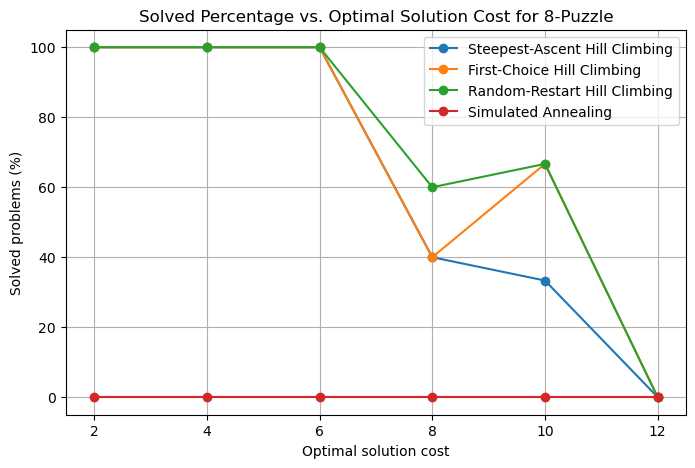

In [73]:
plot_metric(
    "8-puzzle",
    "solved_percentage",
    "Solved problems (%)",
    "Solved Percentage vs. Optimal Solution Cost for 8-Puzzle"
)

**Fig. 1. Solved percentage versus optimal solution cost for 8-puzzle.**

Fig. 1 shows how the probability of solving an 8-puzzle instance changes as the optimal solution cost increases.

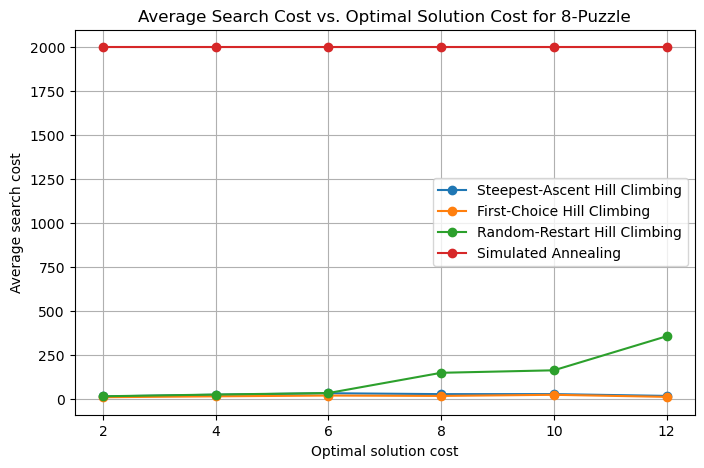

In [74]:
plot_metric(
    "8-puzzle",
    "avg_search_cost",
    "Average search cost",
    "Average Search Cost vs. Optimal Solution Cost for 8-Puzzle"
)

**Fig. 2. Average search cost versus optimal solution cost for 8-puzzle.**

Fig. 2 compares the amount of search effort required by each algorithm on 8-puzzle instances of different optimal solution costs.

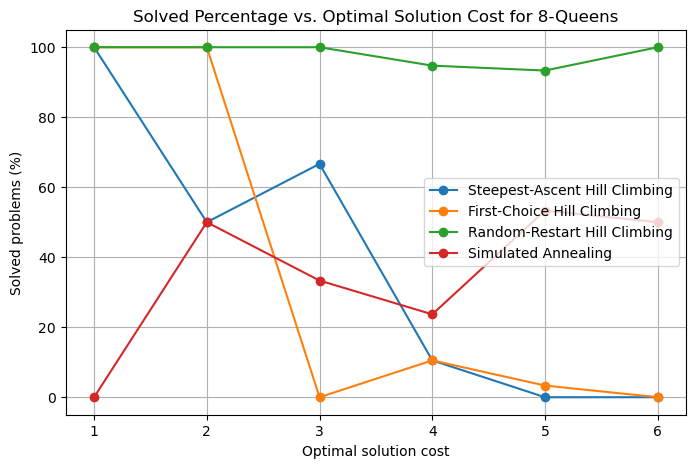

In [75]:
plot_metric(
    "8-queens",
    "solved_percentage",
    "Solved problems (%)",
    "Solved Percentage vs. Optimal Solution Cost for 8-Queens"
)

**Fig. 3. Solved percentage versus optimal solution cost for 8-queens.**

Fig. 3 shows how often each algorithm solves 8-queens instances as the initial board becomes farther from a valid solution.

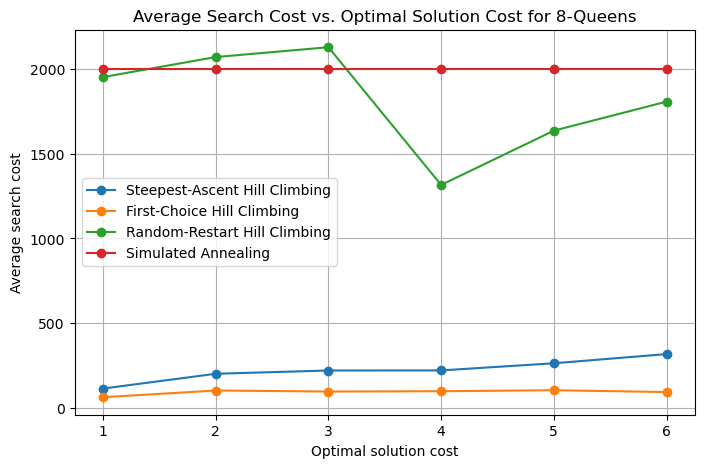

In [76]:
plot_metric(
    "8-queens",
    "avg_search_cost",
    "Average search cost",
    "Average Search Cost vs. Optimal Solution Cost for 8-Queens"
)

**Fig. 4. Average search cost versus optimal solution cost for 8-queens.**

Fig. 4 compares the average search cost of the algorithms on 8-queens instances grouped by optimal solution cost.

## XII. Analysis and Discussion

Table III and Table IV should be used together to compare the algorithms. Table III shows how performance changes as optimal solution cost increases, while Table IV gives an overall comparison.

For 8-puzzle, the solved percentage is expected to decrease as the optimal solution cost increases. A state farther from the goal may require moves that do not immediately improve the Manhattan-distance value function, so hill climbing can stop before reaching the goal.

For 8-queens, local search usually performs better because the value function directly measures the number of attacking queen pairs. Still, simple hill climbing can stop at local optima where moving one queen does not immediately improve the board. Random-restart hill climbing generally improves solved percentage because multiple attempts increase the chance of starting near a good solution region.

Simulated annealing can perform better than simple hill climbing when escaping a local optimum requires temporarily accepting a worse state. However, its performance depends strongly on the cooling schedule. If the temperature decreases too quickly, it behaves almost like normal hill climbing. If it decreases too slowly, search cost can increase.

## XIII. Conclusion

The results demonstrate the tradeoff between search cost and solution reliability. Steepest-ascent hill climbing is simple and often cheap, but it can get stuck. First-choice hill climbing can reduce neighbor evaluations but has the same basic local-optimum problem. Random-restart hill climbing improves the probability of finding a solution but increases total cost. Simulated annealing can escape some local optima by accepting worse states early in the search, but it depends on the temperature schedule.

Overall, the experiment shows that local search methods can be efficient, but their success depends heavily on the problem structure, value function, and restart or randomness strategy.

## XIV. References

[1] S. Russell and P. Norvig, *Artificial Intelligence: A Modern Approach*, 4th ed. Hoboken, NJ, USA: Pearson, 2020.

[2] AIMA Exercises, “Exercise 4.4,” *AIMA Exercises*. Accessed: Apr. 25, 2026. [Online]. Available: https://aimacode.github.io/aima-exercises/advanced-search-exercises/ex_4/

[3] aimacode, “aima-python,” GitHub. Accessed: Apr. 25, 2026. [Online]. Available: https://github.com/aimacode/aima-python

[4] IEEE Author Center, “IEEE Reference Guide.” Accessed: Apr. 25, 2026. [Online]. Available: https://journals.ieeeauthorcenter.ieee.org/